# Notebook 01 — Datasets
## Adaptive Reliability-Aware Fusion (ARAF) Project

**Goal of this notebook:**  
Understand and load the VQA v2 dataset, inspect raw samples, define the
`MultimodalSample` dataclass (the shared data contract for the whole project),
and verify that our loaders produce correctly shaped tensors.

**Why we do this first:**  
Every later component — corruption, encoders, fusion, training — depends on
receiving data in a consistent format. Nailing the data contract now means
zero debugging surprises later.

**What you will learn:**
- What a VQA v2 sample looks like (image, question, label)
- How images are represented as tensors
- How text is tokenized into integer IDs
- Why we use soft labels instead of hard one-hot labels
- How to write a dataset loader that is reusable for Hateful Memes later

---


## 1. Install dependencies

We install the minimum required libraries. Each serves a specific purpose:
- `torch` + `torchvision` — tensor operations and image transforms
- `transformers` — BERT tokenizer for text
- `datasets` — HuggingFace hub, gives us VQA v2 without manual download
- `Pillow` — image loading and display
- `matplotlib` — visualization


In [1]:
# Run this cell once. Restart the kernel if prompted after installation.
import subprocess, sys

pkgs = [
    "torch", "torchvision",
    "transformers",
    "datasets",
    "Pillow",
    "matplotlib",
]

for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All dependencies installed.")


All dependencies installed.


## 2. Imports

We group imports by responsibility so it's clear why each module is here.


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import json
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Tuple
from pathlib import Path

# ── Numerics & visualization ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── PyTorch ────────────────────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader

# ── Vision ─────────────────────────────────────────────────────────────────────
from torchvision import transforms
from PIL import Image
import requests
from io import BytesIO

# ── Language ───────────────────────────────────────────────────────────────────
from transformers import BertTokenizer

# ── HuggingFace datasets ───────────────────────────────────────────────────────
from datasets import load_dataset

print("Imports successful.")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {DEVICE}")


Imports successful.
PyTorch version : 2.5.1+cu118
CUDA available  : True
Using device    : cuda


## 3. The `MultimodalSample` dataclass — our data contract

### Why define this?

Think of `MultimodalSample` as an API contract between components. Every part
of the project (dataset loaders, corruption module, model, evaluator) speaks
this one format. If we ever add a third dataset, we just write a new loader
that produces `MultimodalSample` objects — nothing else changes.

### What each field means

| Field | Shape | dtype | Meaning |
|---|---|---|---|
| `image` | `[3, 224, 224]` | float32 | Normalized RGB pixels |
| `text_ids` | `[seq_len]` | int64 | Tokenized question as integer IDs |
| `attention_mask` | `[seq_len]` | int64 | 1 for real tokens, 0 for padding |
| `label` | `[num_classes]` | float32 | Soft score vector (VQA) or scalar (Hateful Memes) |
| `raw_image` | PIL Image | — | Kept for visualization only, not used by model |
| `raw_text` | str | — | Original question string, for debugging |
| `image_corrupted` | bool | — | Set by corruption module |
| `text_corrupted` | bool | — | Set by corruption module |
| `image_missing` | bool | — | Set by corruption module |
| `text_missing` | bool | — | Set by corruption module |
| `corruption_severity` | float | — | 0.0 = clean, 1.0 = max corruption |
| `dataset_name` | str | — | "vqa_v2" or "hateful_memes" |
| `sample_id` | str | — | Unique ID for logging/debugging |

### Why soft labels?

VQA v2 collected 10 answers per question from different annotators. Instead of
picking one, we keep a score: if 7/10 annotators said "yellow", that answer
gets score min(7/10 * 1.3, 1.0) = 0.91. This is the official VQA scoring
formula. We train with BCE loss over these soft scores, not cross-entropy over
a hard label. This matters: a model that produces the second-most-common answer
should be partially credited.


In [3]:
@dataclass
class MultimodalSample:
    """
    Shared data contract for all datasets in the ARAF project.
    
    The corruption module will fill in the corruption_* fields.
    The model never sees raw_image or raw_text — those are for us humans.
    """
    # ── Core tensors (what the model sees) ────────────────────────────────────
    image: torch.Tensor                    # [3, H, W], normalized float32
    text_ids: torch.Tensor                 # [seq_len], int64
    attention_mask: torch.Tensor           # [seq_len], int64
    label: torch.Tensor                    # [num_classes] float32 (soft) or scalar

    # ── Human-readable fields (for visualization & debugging) ─────────────────
    raw_image: Optional[object] = None     # PIL Image
    raw_text: str = ""                     # original question/caption string
    dataset_name: str = "vqa_v2"
    sample_id: str = ""

    # ── Corruption metadata (filled by corruption module, NOT by loader) ───────
    image_corrupted: bool = False
    text_corrupted: bool = False
    image_missing: bool = False
    text_missing: bool = False
    corruption_severity: float = 0.0       # 0.0 = clean, 1.0 = max

    def summary(self) -> str:
        """Print a human-readable summary of this sample."""
        lines = [
            f"Dataset      : {self.dataset_name}",
            f"Sample ID    : {self.sample_id}",
            f"Text         : '{self.raw_text}'",
            f"Image shape  : {tuple(self.image.shape)}",
            f"Text IDs     : {self.text_ids[:8].tolist()} ... (len={len(self.text_ids)})",
            f"Label shape  : {tuple(self.label.shape)}",
            f"Top label    : index {self.label.argmax().item()} "
              f"(score {self.label.max().item():.3f})",
            f"Corrupted?   : image={self.image_corrupted}, "
              f"text={self.text_corrupted}",
        ]
        return "\n".join(lines)

# Quick sanity check — create a dummy sample to verify the dataclass works
dummy = MultimodalSample(
    image=torch.zeros(3, 224, 224),
    text_ids=torch.zeros(32, dtype=torch.long),
    attention_mask=torch.ones(32, dtype=torch.long),
    label=torch.zeros(3129),
    raw_text="What color is the bus?",
    dataset_name="vqa_v2",
    sample_id="dummy_001",
)
print("MultimodalSample created successfully.")
print(dummy.summary())


MultimodalSample created successfully.
Dataset      : vqa_v2
Sample ID    : dummy_001
Text         : 'What color is the bus?'
Image shape  : (3, 224, 224)
Text IDs     : [0, 0, 0, 0, 0, 0, 0, 0] ... (len=32)
Label shape  : (3129,)
Top label    : index 0 (score 0.000)
Corrupted?   : image=False, text=False


## 4. Image transforms — from pixels to tensors

### Why these specific numbers?

The normalization mean `[0.485, 0.456, 0.406]` and std `[0.229, 0.224, 0.225]`
are ImageNet statistics. Our image encoder (ResNet or ViT) was pretrained on
ImageNet, so it expects inputs normalized this way. Using different statistics
would be like speaking to someone in the wrong language — the encoder would
produce meaningless features.

### What each transform does

1. `Resize(224, 224)` — standardize spatial dimensions. All images must be
   the same size to batch them as tensors.
2. `ToTensor()` — converts PIL Image (H, W, 3), uint8 [0,255] to
   tensor (3, H, W), float32 [0.0, 1.0].
3. `Normalize(mean, std)` — shifts each channel so the encoder sees values
   centered around zero. This speeds up training significantly.

### Order matters

Always: Resize → ToTensor → Normalize.  
Never normalize before converting to a float tensor.


In [4]:
# ── Standard ImageNet normalization constants ──────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE    = 224

# ── Transform for CLEAN images (used during training on clean data) ───────────
clean_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),                          # [0,255] uint8 → [0,1] float
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Transform WITHOUT normalization (used for visualization only) ─────────────
# We need this to display images that look correct to human eyes.
viz_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """
    Reverse ImageNet normalization for display.
    Input : tensor [3, H, W], normalized float32
    Output: numpy array [H, W, 3], uint8 [0, 255]
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img  = tensor * std + mean          # undo normalization
    img  = img.clamp(0, 1)             # clip to valid range
    img  = (img * 255).byte()          # float [0,1] → uint8 [0,255]
    return img.permute(1, 2, 0).numpy()  # [3,H,W] → [H,W,3]

print("Transforms defined.")
print(f"Clean transform: {clean_transform}")


Transforms defined.
Clean transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 5. Text tokenizer — from strings to integer IDs

### Why BERT tokenizer?

BERT's tokenizer was trained on a large English corpus and uses WordPiece
subword tokenization. This means it can handle unseen words by splitting them
into known subword pieces. For example:
- `"skateboarding"` → `["skate", "##boarding"]` → `[22403, 15475]`

This is better than word-level tokenization (which breaks on rare words) and
character-level (which produces very long sequences).

### Special tokens you must know

- `[CLS]` (ID=101): Always prepended. BERT uses its representation for
  classification tasks. Our text encoder will use this.
- `[SEP]` (ID=102): Marks end of sequence.
- `[PAD]` (ID=0): Fills shorter sequences to `max_length` so we can batch them.
- `[MASK]` (ID=103): Used by our text corruption module to mask tokens.

### Attention mask

The attention mask tells the encoder which tokens are real (1) vs. padding (0).
The encoder must not attend to padding tokens — they carry no information.


In [5]:
# Load BERT tokenizer — downloads once, cached locally after that
print("Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

# ── Demonstrate tokenization ──────────────────────────────────────────────────
example_questions = [
    "What color is the bus?",
    "How many people are in the image?",
    "Is there a dog in the picture?",
]

print("\n--- Tokenization examples ---")
for q in example_questions:
    tokens = tokenizer.tokenize(q)
    ids    = tokenizer.convert_tokens_to_ids(tokens)
    print(f"\nQuestion : {q}")
    print(f"Tokens   : {tokens}")
    print(f"IDs      : {ids}")

# ── Demonstrate padding and attention mask ────────────────────────────────────
print("\n--- Batch encoding (with padding) ---")
encoded = tokenizer(
    example_questions,
    padding="max_length",   # pad all sequences to max_length
    max_length=32,          # we use 32 for VQA (questions are short)
    truncation=True,
    return_tensors="pt",    # return PyTorch tensors
)

print(f"input_ids shape     : {encoded['input_ids'].shape}")
print(f"attention_mask shape: {encoded['attention_mask'].shape}")
print(f"\nFirst sequence IDs  : {encoded['input_ids'][0].tolist()}")
print(f"First attention mask: {encoded['attention_mask'][0].tolist()}")
print(f"\nSpecial token IDs:")
print(f"  [CLS]  = {tokenizer.cls_token_id}")
print(f"  [SEP]  = {tokenizer.sep_token_id}")
print(f"  [PAD]  = {tokenizer.pad_token_id}")
print(f"  [MASK] = {tokenizer.mask_token_id}")

MAX_TEXT_LEN = 32  # we'll use this constant everywhere


Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabulary size: 30,522

--- Tokenization examples ---

Question : What color is the bus?
Tokens   : ['what', 'color', 'is', 'the', 'bus', '?']
IDs      : [2054, 3609, 2003, 1996, 3902, 1029]

Question : How many people are in the image?
Tokens   : ['how', 'many', 'people', 'are', 'in', 'the', 'image', '?']
IDs      : [2129, 2116, 2111, 2024, 1999, 1996, 3746, 1029]

Question : Is there a dog in the picture?
Tokens   : ['is', 'there', 'a', 'dog', 'in', 'the', 'picture', '?']
IDs      : [2003, 2045, 1037, 3899, 1999, 1996, 3861, 1029]

--- Batch encoding (with padding) ---
input_ids shape     : torch.Size([3, 32])
attention_mask shape: torch.Size([3, 32])

First sequence IDs  : [101, 2054, 3609, 2003, 1996, 3902, 1029, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
First attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Special token IDs:
  [CLS]  = 101
  [SEP]  = 102
  [PAD]  = 0
  [MASK] = 10

## 6. VQA v2 answer vocabulary

VQA v2 treats answering as classification over the **3,129 most frequent
answers** in the training set. Answers outside this set are ignored during
training (they're very rare).

We build two mappings:
- `answer2idx`: `"yes" → 0`, `"no" → 1`, `"2" → 2`, etc.
- `idx2answer`: the reverse, for converting predictions back to strings.

We also implement the **official VQA soft scoring formula:**  
`score = min(count / 3, 1.0)` where `count` is how many of the 10 annotators
gave that answer. This rewards answers most annotators agreed on, and
partially credits plausible alternatives.


In [10]:
def build_answer_vocab(dataset_split, top_k: int = 3129) -> Tuple[Dict, Dict]:
    """
    Build answer vocabulary from the training split.
    
    Args:
        dataset_split : HuggingFace dataset split (train)
        top_k         : keep only the top_k most common answers
    
    Returns:
        answer2idx : dict mapping answer string → index
        idx2answer : dict mapping index → answer string
    """
    from collections import Counter
    counter = Counter()
    
    print(f"Scanning {len(dataset_split):,} samples for answers...")
    for sample in dataset_split:
        for ans in sample["answers"]:
            counter[ans["answer"].lower().strip()] += 1
    
    # Keep only top_k answers
    most_common = [ans for ans, _ in counter.most_common(top_k)]
    
    answer2idx = {ans: idx for idx, ans in enumerate(most_common)}
    idx2answer = {idx: ans for ans, idx in answer2idx.items()}
    
    print(f"Vocabulary built: {len(answer2idx):,} answers")
    print(f"Coverage: top answer='{most_common[0]}', "
          f"rank-10='{most_common[9]}', rank-100='{most_common[99]}'")
    return answer2idx, idx2answer


def make_soft_label(answers: List[Dict], answer2idx: Dict,
                    num_classes: int = 3129) -> torch.Tensor:
    """
    Convert a list of 10 annotator answers to a soft score vector.
    
    Official VQA scoring: score = min(count / 3, 1.0)
    
    Args:
        answers    : list of dicts with key 'answer', from HuggingFace
        answer2idx : vocabulary mapping
        num_classes: vocabulary size
    
    Returns:
        label : float32 tensor of shape [num_classes]
    
    Example:
        If 6 annotators said "yellow" and 4 said "orange":
          yellow score = min(6/3, 1.0) = 1.0
          orange score = min(4/3, 1.0) = 1.0  (both saturate)
        If 2 annotators said "yellow":
          yellow score = min(2/3, 1.0) = 0.67  (partial credit)
    """
    from collections import Counter
    label = torch.zeros(num_classes, dtype=torch.float32)
    
    count = Counter(a["answer"].lower().strip() for a in answers)
    for ans, cnt in count.items():
        if ans in answer2idx:
            score = min(cnt / 3.0, 1.0)   # official VQA formula
            label[answer2idx[ans]] = score
    
    return label


# ── Demonstrate soft label ────────────────────────────────────────────────────
# We'll simulate what 10 annotators might say
simulated_answers = [
    {"answer": "yellow"}, {"answer": "yellow"}, {"answer": "yellow"},
    {"answer": "yellow"}, {"answer": "yellow"}, {"answer": "yellow"},
    {"answer": "orange"}, {"answer": "orange"},
    {"answer": "red"},
    {"answer": "yellow"},  # 7 yellow, 2 orange, 1 red
]
# Build a tiny vocab for demonstration
demo_vocab = {"yellow": 0, "orange": 1, "red": 2, "blue": 3}
demo_label = make_soft_label(simulated_answers, demo_vocab, num_classes=4)

print("Soft label demonstration:")
print(f"  yellow (7/10): score = {demo_label[0]:.3f}  "
      f"(min(7/3, 1.0) = {min(7/3, 1.0):.3f})")
print(f"  orange (2/10): score = {demo_label[1]:.3f}  "
      f"(min(2/3, 1.0) = {min(2/3, 1.0):.3f})")
print(f"  red    (1/10): score = {demo_label[2]:.3f}  "
      f"(min(1/3, 1.0) = {min(1/3, 1.0):.3f})")
print(f"  blue   (0/10): score = {demo_label[3]:.3f}")


Soft label demonstration:
  yellow (7/10): score = 1.000  (min(7/3, 1.0) = 1.000)
  orange (2/10): score = 0.667  (min(2/3, 1.0) = 0.667)
  red    (1/10): score = 0.333  (min(1/3, 1.0) = 0.333)
  blue   (0/10): score = 0.000


## 7. VQA v2 Dataset class

This is the main loader. It:
1. Wraps the HuggingFace VQA v2 dataset
2. Applies image transforms
3. Tokenizes text
4. Converts answers to soft score labels
5. Returns a `MultimodalSample` for every `__getitem__` call

### Design note: why `max_samples`?

VQA v2 has ~200k training samples. For development we use a small subset (e.g.
500 samples) so cells run in seconds. Once the full pipeline is validated, set
`max_samples=None` to use everything.

### Design note: why load images from URLs lazily?

VQA v2 on HuggingFace stores images as PIL Images in the dataset object. We
transform them on-the-fly in `__getitem__` rather than pre-transforming all of
them, because:
- Pre-transforming 200k images takes significant RAM
- On-the-fly is standard practice, enabled by PyTorch DataLoader workers


In [11]:
class VQAv2Dataset(Dataset):
    """
    PyTorch Dataset wrapping the HuggingFace VQA v2 dataset.
    
    Produces MultimodalSample objects with:
      - image      : [3, 224, 224] float32, ImageNet-normalized
      - text_ids   : [MAX_TEXT_LEN] int64, BERT tokenized question
      - attention_mask: [MAX_TEXT_LEN] int64
      - label      : [num_classes] float32, soft VQA scores
    
    Args:
        hf_split   : HuggingFace dataset split (already loaded)
        tokenizer  : BertTokenizer instance
        answer2idx : answer vocabulary dict
        transform  : torchvision transform for images
        max_samples: if not None, use only first N samples (for dev)
        num_classes: vocabulary size (default 3129)
    """
    
    def __init__(
        self,
        hf_split,
        tokenizer: BertTokenizer,
        answer2idx: Dict[str, int],
        transform=None,
        max_samples: Optional[int] = None,
        num_classes: int = 3129,
    ):
        self.data        = hf_split
        self.tokenizer   = tokenizer
        self.answer2idx  = answer2idx
        self.transform   = transform or clean_transform
        self.num_classes = num_classes
        
        # Optionally limit dataset size for fast development
        if max_samples is not None:
            self.data = self.data.select(range(min(max_samples, len(self.data))))
        
        print(f"VQAv2Dataset initialized: {len(self.data):,} samples")
    
    def __len__(self) -> int:
        return len(self.data)
    
    def __getitem__(self, idx: int) -> MultimodalSample:
        row = self.data[idx]
        
        # ── 1. Image ──────────────────────────────────────────────────────────
        # HuggingFace VQA v2 stores images as PIL objects in 'image' field
        pil_image = row["image"].convert("RGB")   # ensure 3-channel RGB
        image_tensor = self.transform(pil_image)  # → [3, 224, 224]
        
        # ── 2. Text (question) ────────────────────────────────────────────────
        question = row["question"]
        encoded  = self.tokenizer(
            question,
            padding="max_length",
            max_length=MAX_TEXT_LEN,
            truncation=True,
            return_tensors="pt",
        )
        text_ids      = encoded["input_ids"].squeeze(0)       # [MAX_TEXT_LEN]
        attention_mask = encoded["attention_mask"].squeeze(0) # [MAX_TEXT_LEN]
        
        # ── 3. Label (soft scores) ────────────────────────────────────────────
        label = make_soft_label(
            row["answers"], self.answer2idx, self.num_classes
        )
        
        # ── 4. Build MultimodalSample ─────────────────────────────────────────
        return MultimodalSample(
            image          = image_tensor,
            text_ids       = text_ids,
            attention_mask = attention_mask,
            label          = label,
            raw_image      = pil_image,          # for visualization
            raw_text       = question,           # for debugging
            dataset_name   = "vqa_v2",
            sample_id      = str(row.get("question_id", idx)),
        )
    
    def get_answer_string(self, label_tensor: torch.Tensor) -> str:
        """Convert a soft label tensor back to the top answer string."""
        idx2answer = {v: k for k, v in self.answer2idx.items()}
        top_idx    = label_tensor.argmax().item()
        return idx2answer.get(top_idx, "<unknown>")


print("VQAv2Dataset class defined.")


VQAv2Dataset class defined.


## 8. Load VQA v2 from HuggingFace

This downloads the dataset on first run (~1-2 minutes) and caches it locally.
Subsequent runs load from cache instantly.

We use a small `max_samples` value here so you can explore quickly. For full
training, set `MAX_TRAIN_SAMPLES = None`.

**Note:** HuggingFace VQA v2 (`HuggingFaceM4/VQAv2`) provides train, validation,
and a test split. We use `validation` for quick loading because it's smaller
than train and still representative.


In [12]:
# ── Configuration ─────────────────────────────────────────────────────────────
MAX_TRAIN_SAMPLES = 2000   # set to None for full dataset
MAX_VAL_SAMPLES   = 500

print("Loading VQA v2 from HuggingFace hub...")
print("(First run downloads data — subsequent runs use cache)\n")

# lmms-lab/VQAv2 only has validation/testdev/test splits (no train)
# We load validation and split it ourselves 80/20
hf_val_full = load_dataset("lmms-lab/VQAv2", split="validation", trust_remote_code=True)

print(f"Full validation split size: {len(hf_val_full):,}")
print(f"Sample keys: {list(hf_val_full[0].keys())}")

# Split 80/20 into our own train and val
split    = hf_val_full.train_test_split(test_size=0.2, seed=42)
hf_train = split["train"]
hf_val   = split["test"]

print(f"\nOur train split : {len(hf_train):,}")
print(f"Our val split   : {len(hf_val):,}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lmms-lab/VQAv2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading VQA v2 from HuggingFace hub...
(First run downloads data — subsequent runs use cache)



Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/67 [00:00<?, ?it/s]

Full validation split size: 214,354
Sample keys: ['question_type', 'multiple_choice_answer', 'answers', 'image_id', 'answer_type', 'question_id', 'question', 'image']

Our train split : 171,483
Our val split   : 42,871


In [13]:
# ── Build answer vocabulary from training split ────────────────────────────────
# We scan the FULL training split for vocab (even if we only train on a subset)
# This ensures our vocabulary is comprehensive.
answer2idx, idx2answer = build_answer_vocab(hf_train, top_k=3129)

# Save vocabulary for later notebooks
vocab_path = Path("answer_vocab.json")
with open(vocab_path, "w") as f:
    json.dump(answer2idx, f)
print(f"\nVocabulary saved to {vocab_path}")


Scanning 171,483 samples for answers...
Vocabulary built: 3,129 answers
Coverage: top answer='no', rank-10='0', rank-100='sitting'

Vocabulary saved to answer_vocab.json


In [14]:
# ── Create Dataset objects ─────────────────────────────────────────────────────
split = hf_val.train_test_split(test_size=0.2, seed=42)

train_dataset = VQAv2Dataset(
    hf_split    = split["train"],
    tokenizer   = tokenizer,
    answer2idx  = answer2idx,
    max_samples = MAX_TRAIN_SAMPLES,
)

val_dataset = VQAv2Dataset(
    hf_split    = split["test"],
    tokenizer   = tokenizer,
    answer2idx  = answer2idx,
    max_samples = MAX_VAL_SAMPLES,
)
# ── Create DataLoaders ────────────────────────────────────────────────────────
# DataLoader handles batching, shuffling, and parallel loading
# num_workers=0 is safest on Windows; increase on Linux for speed
train_loader = DataLoader(
    train_dataset,
    batch_size  = 32,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = torch.cuda.is_available(),
    collate_fn  = None,   # default collation works because all tensors are same shape
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = 32,
    shuffle     = False,
    num_workers = 0,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")


VQAv2Dataset initialized: 2,000 samples
VQAv2Dataset initialized: 500 samples
Train batches : 63
Val batches   : 16


## 9. Inspect individual samples

Before training anything, always look at your data. This is the single most
important habit in ML research. We check:
- Does the image look correct?
- Does the question make sense?
- Is the label reasonable?
- Are tensor shapes correct?


In [15]:
# ── Print summary of first 3 samples ──────────────────────────────────────────
print("=" * 60)
print("SAMPLE INSPECTION")
print("=" * 60)

for i in range(3):
    sample = train_dataset[i]
    print(f"\n{'─'*50}")
    print(f"Sample {i}:")
    print(sample.summary())

# ── Verify tensor shapes and dtypes ───────────────────────────────────────────
sample = train_dataset[0]
print(f"\n{'─'*50}")
print("TENSOR VERIFICATION")
print(f"image dtype          : {sample.image.dtype}")
print(f"image shape          : {tuple(sample.image.shape)}")
print(f"image value range    : [{sample.image.min():.3f}, {sample.image.max():.3f}]")
print(f"  (normalized, so range outside [0,1] is expected)")
print(f"text_ids dtype       : {sample.text_ids.dtype}")
print(f"text_ids shape       : {tuple(sample.text_ids.shape)}")
print(f"attention_mask shape : {tuple(sample.attention_mask.shape)}")
print(f"label dtype          : {sample.label.dtype}")
print(f"label shape          : {tuple(sample.label.shape)}")
print(f"label sum            : {sample.label.sum():.3f}  (how many answers scored)")
print(f"top answer           : '{train_dataset.get_answer_string(sample.label)}'")


SAMPLE INSPECTION

──────────────────────────────────────────────────
Sample 0:
Dataset      : vqa_v2
Sample ID    : 247407003
Text         : 'Is the man wearing a watch?'
Image shape  : (3, 224, 224)
Text IDs     : [101, 2003, 1996, 2158, 4147, 1037, 3422, 1029] ... (len=32)
Label shape  : (3129,)
Top label    : index 1 (score 1.000)
Corrupted?   : image=False, text=False

──────────────────────────────────────────────────
Sample 1:
Dataset      : vqa_v2
Sample ID    : 560371001
Text         : 'Is it a sunny day?'
Image shape  : (3, 224, 224)
Text IDs     : [101, 2003, 2009, 1037, 11559, 2154, 1029, 102] ... (len=32)
Label shape  : (3129,)
Top label    : index 0 (score 1.000)
Corrupted?   : image=False, text=False

──────────────────────────────────────────────────
Sample 2:
Dataset      : vqa_v2
Sample ID    : 527704003
Text         : 'Where is a sidewalk item required by the Americans with Disabilities Act?'
Image shape  : (3, 224, 224)
Text IDs     : [101, 2073, 2003, 1037, 11996, 

## 10. Visualize samples

Seeing the actual images and questions is essential. We display 6 samples in a
grid, showing the image, question, and top answer for each.


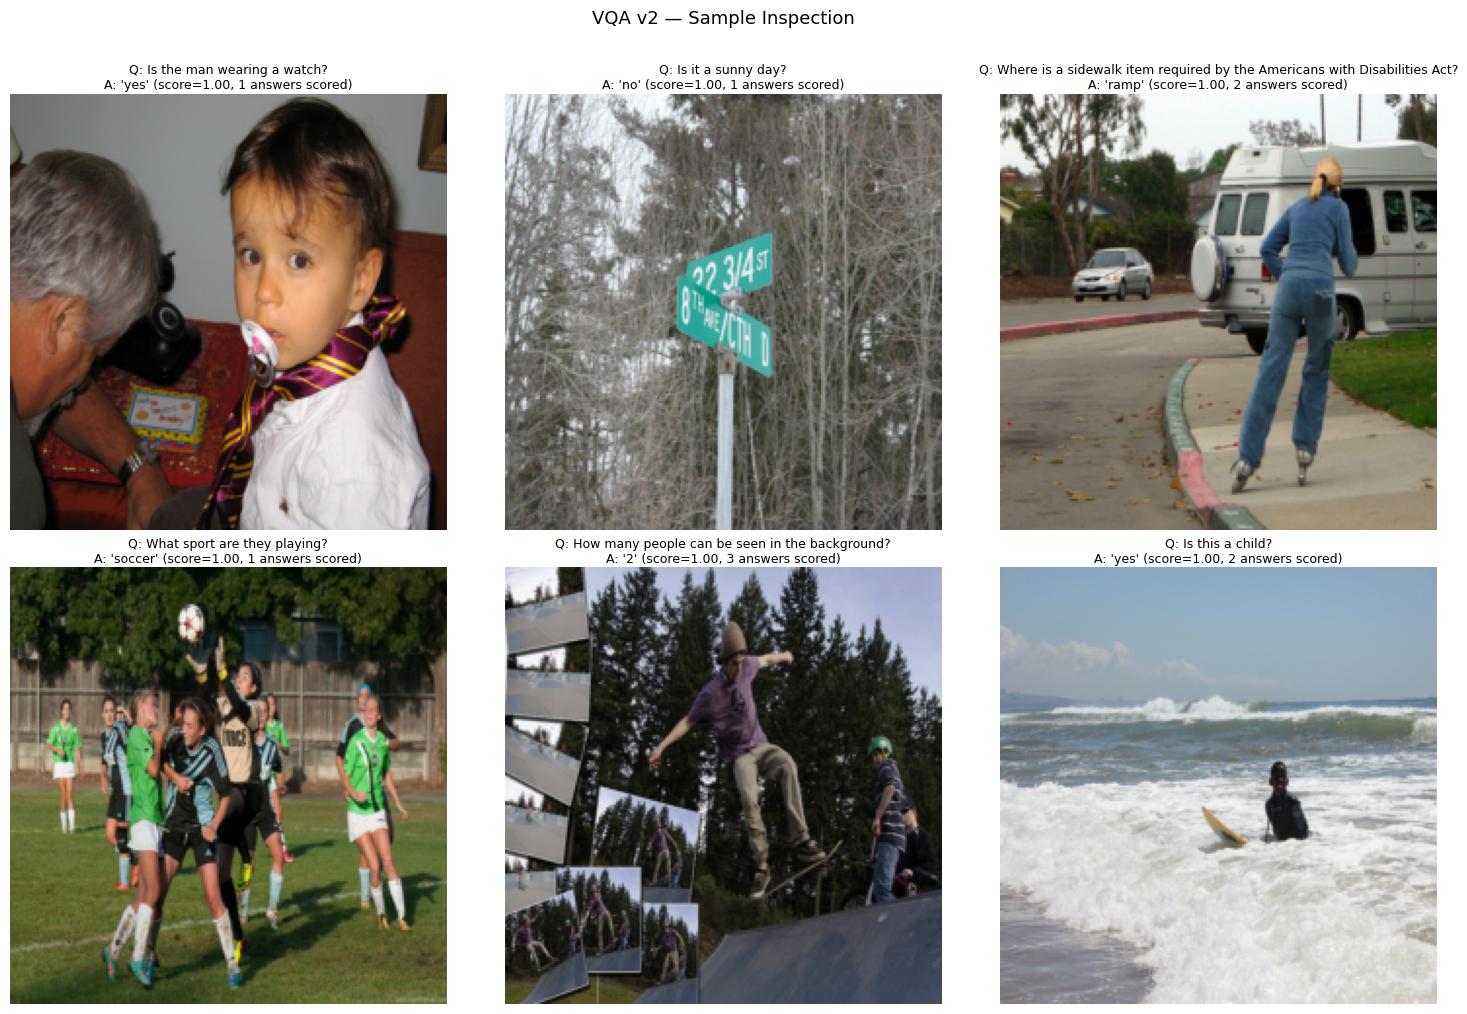

Saved to vqa_samples.png


In [16]:
def visualize_samples(dataset: VQAv2Dataset, n: int = 6, cols: int = 3):
    """
    Display n samples from the dataset in a grid.
    Shows: image, question, top answer, and label score.
    """
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    axes = axes.flatten()
    
    for i in range(n):
        sample = dataset[i]
        ax = axes[i]
        
        # Display the image (denormalized for correct colors)
        img_display = denormalize(sample.image)
        ax.imshow(img_display)
        
        # Get top answer and its score
        top_idx    = sample.label.argmax().item()
        top_score  = sample.label.max().item()
        top_answer = dataset.get_answer_string(sample.label)
        num_scored = (sample.label > 0).sum().item()
        
        # Title: question on top, answer below
        ax.set_title(
            f"Q: {sample.raw_text}\n"
            f"A: '{top_answer}' (score={top_score:.2f}, "
            f"{num_scored} answers scored)",
            fontsize=9, pad=4
        )
        ax.axis("off")
    
    # Hide any unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")
    
    plt.suptitle("VQA v2 — Sample Inspection", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("vqa_samples.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved to vqa_samples.png")

visualize_samples(train_dataset, n=6)


## 11. Label distribution analysis

Understanding the label distribution is critical for training decisions:
- Is the dataset class-balanced or imbalanced?
- What are the most common answers?
- How many samples have a clear single answer vs. many equally scored answers?

This will inform our loss function choice and whether we need class weighting.


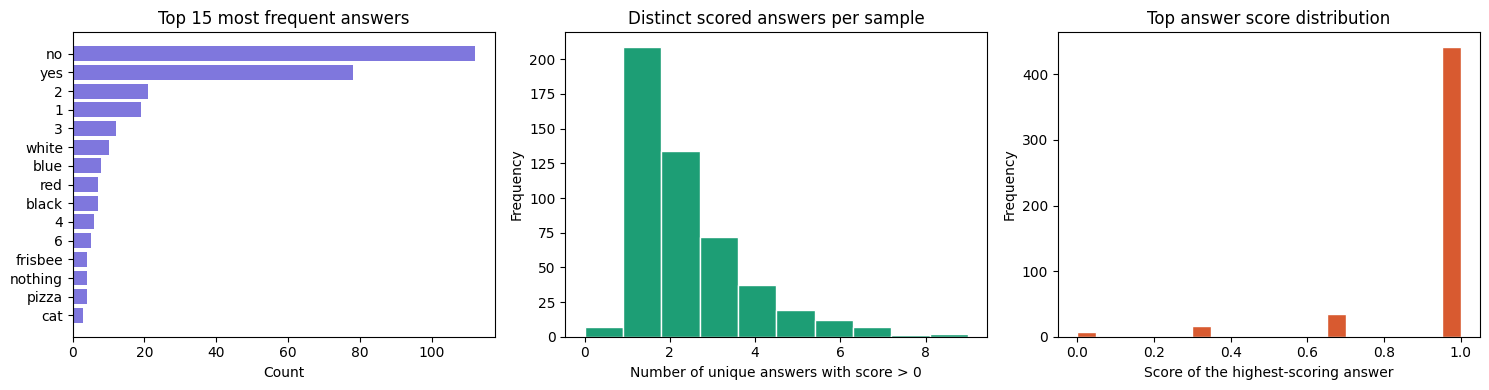

Analyzed 500 samples

Most common answers:
  'no': 112 (22.4%)
  'yes': 78 (15.6%)
  '2': 21 (4.2%)
  '1': 19 (3.8%)
  '3': 12 (2.4%)
  'white': 10 (2.0%)
  'blue': 8 (1.6%)
  'red': 7 (1.4%)
  'black': 7 (1.4%)
  '4': 6 (1.2%)

Label stats:
  Avg distinct answers per sample : 2.17
  Avg top answer score            : 0.941
  Samples with perfect score (1.0): 442 (88.4%)

Note: 'yes' and 'no' are typically the most common answers
in VQA v2, followed by numbers. This mild class imbalance
is handled by soft labels + BCE loss (not cross-entropy).


In [17]:
def analyze_label_distribution(dataset: VQAv2Dataset, n_samples: int = 500):
    """
    Analyze the distribution of top answers and label properties.
    """
    from collections import Counter
    
    top_answers   = Counter()
    label_sums    = []    # how many distinct answers per sample
    top_scores    = []    # score of the top answer per sample
    
    n = min(n_samples, len(dataset))
    for i in range(n):
        sample = dataset[i]
        answer = dataset.get_answer_string(sample.label)
        top_answers[answer] += 1
        label_sums.append((sample.label > 0).sum().item())
        top_scores.append(sample.label.max().item())
    
    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Top 15 most common answers
    top15   = top_answers.most_common(15)
    answers = [a for a, _ in top15]
    counts  = [c for _, c in top15]
    axes[0].barh(answers[::-1], counts[::-1], color="#7F77DD")
    axes[0].set_title("Top 15 most frequent answers")
    axes[0].set_xlabel("Count")
    
    # Distribution of label sum (how many answers scored per sample)
    axes[1].hist(label_sums, bins=10, color="#1D9E75", edgecolor="white")
    axes[1].set_title("Distinct scored answers per sample")
    axes[1].set_xlabel("Number of unique answers with score > 0")
    axes[1].set_ylabel("Frequency")
    
    # Distribution of top answer score
    axes[2].hist(top_scores, bins=20, color="#D85A30", edgecolor="white")
    axes[2].set_title("Top answer score distribution")
    axes[2].set_xlabel("Score of the highest-scoring answer")
    axes[2].set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.savefig("label_distribution.png", dpi=100, bbox_inches="tight")
    plt.show()
    
    # ── Summary stats ────────────────────────────────────────────────────────
    print(f"Analyzed {n} samples")
    print(f"\nMost common answers:")
    for ans, cnt in top_answers.most_common(10):
        print(f"  '{ans}': {cnt} ({cnt/n*100:.1f}%)")
    print(f"\nLabel stats:")
    print(f"  Avg distinct answers per sample : {np.mean(label_sums):.2f}")
    print(f"  Avg top answer score            : {np.mean(top_scores):.3f}")
    print(f"  Samples with perfect score (1.0): "
          f"{sum(s == 1.0 for s in top_scores)} ({sum(s==1.0 for s in top_scores)/n*100:.1f}%)")
    print(f"\nNote: 'yes' and 'no' are typically the most common answers")
    print(f"in VQA v2, followed by numbers. This mild class imbalance")
    print(f"is handled by soft labels + BCE loss (not cross-entropy).")

analyze_label_distribution(train_dataset, n_samples=500)


## 12. Verify batching through DataLoader

The DataLoader stacks individual samples into batches. We need to verify that
batching works correctly — tensor shapes gain a batch dimension, and all dtypes
are correct.

This also gives us a sense of how fast data loading is.


In [20]:
import time

print("Testing DataLoader batching...")
start = time.time()

# Get one batch from the training loader
# Note: DataLoader returns dicts/tuples — but our custom Dataset returns
# MultimodalSample objects. PyTorch's default collate_fn handles dataclasses
# by stacking the tensor fields and collecting non-tensor fields as lists.

batch_sample = next(iter(train_loader))
elapsed = time.time() - start

print(f"\nBatch loaded in {elapsed:.2f}s")
print(f"\nBatch type: {type(batch_sample)}")

# The default collate_fn stacks tensors into [batch_size, ...] tensors
# and collects other fields as lists
if hasattr(batch_sample, "image"):
    print(f"\nTensor shapes in batch:")
    print(f"  image shape          : {batch_sample.image.shape}")
    print(f"  text_ids shape       : {batch_sample.text_ids.shape}")
    print(f"  attention_mask shape : {batch_sample.attention_mask.shape}")
    print(f"  label shape          : {batch_sample.label.shape}")
else:
    # DataLoader may return a dict-like structure for dataclasses
    # Let's inspect what we got
    print(batch_sample)


Testing DataLoader batching...

Batch loaded in 0.12s

Batch type: <class 'dict'>
{'image': tensor([[[[-0.7308, -0.4226, -0.5082,  ..., -1.1589, -0.8164, -0.6794],
          [-0.6965, -0.5596,  0.1426,  ..., -1.2274, -1.1589, -0.8507],
          [-0.5938, -0.6452, -0.3541,  ..., -1.1932, -1.2445, -1.1418],
          ...,
          [ 0.2796,  0.2967,  0.2967,  ..., -0.0801, -0.0972, -0.0287],
          [ 0.1768,  0.2453,  0.1426,  ..., -0.6281, -0.6281, -0.5596],
          [ 0.2282,  0.1768,  0.1768,  ..., -1.0733, -1.1760, -1.1247]],

         [[-0.5126, -0.1800, -0.2150,  ..., -1.0903, -0.7227, -0.6352],
          [-0.4251, -0.2150,  0.5028,  ..., -1.1604, -1.0903, -0.7752],
          [-0.1800, -0.2500, -0.0049,  ..., -1.1429, -1.1604, -1.0728],
          ...,
          [ 0.1176,  0.1527,  0.1527,  ...,  0.2927,  0.2927,  0.3277],
          [ 0.0126,  0.0826, -0.0224,  ..., -0.3901, -0.3550, -0.2850],
          [ 0.0301,  0.0126, -0.0049,  ..., -1.0203, -1.0903, -0.9853]],

         [

In [19]:
# ── Custom collate_fn to handle MultimodalSample cleanly ─────────────────────
# PyTorch's default collate_fn may struggle with dataclasses containing
# non-tensor fields (PIL images, strings). We write a custom one.

def collate_multimodal(samples: List[MultimodalSample]) -> Dict[str, torch.Tensor]:
    """
    Collate a list of MultimodalSample objects into a batch dict.
    
    Returns a dict of batched tensors (and lists for non-tensor fields).
    This is what the model and training loop receive.
    """
    return {
        # ── Tensors: stacked into [B, ...] ────────────────────────────────────
        "image"          : torch.stack([s.image for s in samples]),
        "text_ids"       : torch.stack([s.text_ids for s in samples]),
        "attention_mask" : torch.stack([s.attention_mask for s in samples]),
        "label"          : torch.stack([s.label for s in samples]),
        
        # ── Metadata: kept as lists ───────────────────────────────────────────
        "raw_text"           : [s.raw_text for s in samples],
        "sample_id"          : [s.sample_id for s in samples],
        "image_corrupted"    : [s.image_corrupted for s in samples],
        "text_corrupted"     : [s.text_corrupted for s in samples],
        "image_missing"      : [s.image_missing for s in samples],
        "text_missing"       : [s.text_missing for s in samples],
        "corruption_severity": [s.corruption_severity for s in samples],
    }


# ── Rebuild DataLoaders with the custom collate_fn ────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size  = 32,
    shuffle     = True,
    num_workers = 0,
    collate_fn  = collate_multimodal,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = 32,
    shuffle     = False,
    num_workers = 0,
    collate_fn  = collate_multimodal,
)

# ── Verify a batch ────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
print("Batch dict keys:", list(batch.keys()))
print(f"\nTensor shapes:")
print(f"  image          : {batch['image'].shape}    # [B, 3, 224, 224]")
print(f"  text_ids       : {batch['text_ids'].shape}       # [B, 32]")
print(f"  attention_mask : {batch['attention_mask'].shape}       # [B, 32]")
print(f"  label          : {batch['label'].shape}     # [B, 3129]")
print(f"\nTensor dtypes:")
print(f"  image          : {batch['image'].dtype}")
print(f"  text_ids       : {batch['text_ids'].dtype}")
print(f"  label          : {batch['label'].dtype}")
print(f"\nBatch metadata:")
print(f"  raw_text[0]    : '{batch['raw_text'][0]}'")
print(f"  sample_id[0]   : '{batch['sample_id'][0]}'")
print(f"  image_corrupted: {batch['image_corrupted'][:3]}  (all False, clean data)")
print(f"\nDataLoader verified.")


Batch dict keys: ['image', 'text_ids', 'attention_mask', 'label', 'raw_text', 'sample_id', 'image_corrupted', 'text_corrupted', 'image_missing', 'text_missing', 'corruption_severity']

Tensor shapes:
  image          : torch.Size([32, 3, 224, 224])    # [B, 3, 224, 224]
  text_ids       : torch.Size([32, 32])       # [B, 32]
  attention_mask : torch.Size([32, 32])       # [B, 32]
  label          : torch.Size([32, 3129])     # [B, 3129]

Tensor dtypes:
  image          : torch.float32
  text_ids       : torch.int64
  label          : torch.float32

Batch metadata:
  raw_text[0]    : 'Is the stadium crowded?'
  sample_id[0]   : '126229000'
  image_corrupted: [False, False, False]  (all False, clean data)

DataLoader verified.


## 13. Save artifacts for later notebooks

We save the vocabulary and configuration so Notebook 02 onwards can load them
without re-running everything.


In [21]:
# ── Save configuration ────────────────────────────────────────────────────────
config = {
    "image_size"      : IMAGE_SIZE,
    "max_text_len"    : MAX_TEXT_LEN,
    "num_classes"     : len(answer2idx),
    "imagenet_mean"   : IMAGENET_MEAN,
    "imagenet_std"    : IMAGENET_STD,
    "tokenizer_name"  : "bert-base-uncased",
    "dataset_name"    : "vqa_v2",
    "max_train_samples": MAX_TRAIN_SAMPLES,
    "max_val_samples" : MAX_VAL_SAMPLES,
}

config_path = Path("config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print("Saved artifacts:")
print(f"  config.json        — dataset & model configuration")
print(f"  answer_vocab.json  — answer vocabulary ({len(answer2idx):,} answers)")
print(f"  vqa_samples.png    — sample visualization")
print(f"  label_distribution.png — label analysis")

print(f"\nConfig:")
for k, v in config.items():
    print(f"  {k}: {v}")


Saved artifacts:
  config.json        — dataset & model configuration
  answer_vocab.json  — answer vocabulary (3,129 answers)
  vqa_samples.png    — sample visualization
  label_distribution.png — label analysis

Config:
  image_size: 224
  max_text_len: 32
  num_classes: 3129
  imagenet_mean: [0.485, 0.456, 0.406]
  imagenet_std: [0.229, 0.224, 0.225]
  tokenizer_name: bert-base-uncased
  dataset_name: vqa_v2
  max_train_samples: 2000
  max_val_samples: 500


## 14. Summary and what's next

### What we accomplished in this notebook

- Defined `MultimodalSample` — the data contract for the entire project
- Built `VQAv2Dataset` — a reusable PyTorch Dataset wrapping HuggingFace VQA v2
- Implemented soft label scoring using the official VQA formula
- Set up BERT tokenization with proper padding and attention masks
- Verified tensor shapes, dtypes, and value ranges
- Built a `collate_multimodal` function for clean batch handling
- Visualized samples and analyzed label distribution
- Saved configuration for later notebooks

### Key design decisions made here

| Decision | Why |
|---|---|
| Soft labels with BCE loss | Official VQA scoring, partial credit for plausible answers |
| BERT tokenizer, max_len=32 | VQA questions are short; 32 tokens is sufficient |
| ImageNet normalization | Pretrained encoder expects this |
| `MultimodalSample` dataclass | Clean interface between all pipeline components |
| Custom `collate_fn` | Handles non-tensor fields gracefully |

### What Notebook 02 covers

**The Corruption Module** — the most important component in ARAF.

We will implement:
- Image corruptions: Gaussian noise, motion blur, occlusion patches
- Text corruptions: token dropout, shuffling, synonym replacement  
- Missing modality simulation: zero-out one or both modalities
- Severity levels: 5 levels from barely perceptible to severe
- Visualization: side-by-side clean vs. corrupted samples

The corruption module will take a `MultimodalSample` and return a corrupted
`MultimodalSample` with the `image_corrupted`, `text_corrupted`, and
`corruption_severity` fields filled in — ready for the model to learn from.
